In [1]:
import pandas as pd
import numpy as np

### `Q-1:` Write a program to create an empty series.

In [2]:
empty = pd.Series()
empty

Series([], dtype: object)

### Q-2: Write a Pandas program to add, subtract, multiple and divide two Pandas Series.



In [3]:
a = pd.Series([1,3,5,7,9])
b = pd.Series([2,4,6,8,10])
print(a + b)
print(a - b)
print(a * b)
print(a / b)


0     3
1     7
2    11
3    15
4    19
dtype: int64
0   -1
1   -1
2   -1
3   -1
4   -1
dtype: int64
0     2
1    12
2    30
3    56
4    90
dtype: int64
0    0.500000
1    0.750000
2    0.833333
3    0.875000
4    0.900000
dtype: float64


### `Q-3` Write a Pandas program to compare the elements of the two Pandas Series.
Sample Series: [2, 4, 6, 8, 10], [1, 3, 5, 7, 10]



In [4]:
a = pd.Series([2, 4, 6, 8, 10])
b = pd.Series([1, 3, 5, 7, 10])
print(a==b)
print(a>b)
print(a<b)

0    False
1    False
2    False
3    False
4     True
dtype: bool
0     True
1     True
2     True
3     True
4    False
dtype: bool
0    False
1    False
2    False
3    False
4    False
dtype: bool


### `Q-5.`Write a function to change the data type of given a column or a Series. Function takes series and data type as input, returns the converted series.
```
series = pd.Series([1,2,'Python', 2.0, True, 100])
change to float type data
```
Note: Read about pd.to_numeric()

In [40]:
def change_dtype(series):
    return pd.to_numeric(series,errors='coerce')
series = pd.Series([1,2,'Python', 2.0, True, 100])
change_dtype(series)

0      1.0
1      2.0
2      NaN
3      2.0
4      1.0
5    100.0
dtype: float64

In [41]:
# data read
data = pd.read_csv('batsman_runs_series.csv',index_col='batter').squeeze()
data

batter
A Ashish Reddy     280
A Badoni           161
A Chandila           4
A Chopra            53
A Choudhary         25
                  ... 
Yash Dayal           0
Yashpal Singh       47
Younis Khan          3
Yuvraj Singh      2754
Z Khan             117
Name: batsman_run, Length: 605, dtype: int64

In [42]:
type(data)


pandas.core.series.Series

 ### Find top 10 most run getter from the series.

In [43]:
data.sort_values(ascending=False).head(10)

batter
V Kohli           6634
S Dhawan          6244
DA Warner         5883
RG Sharma         5881
SK Raina          5536
AB de Villiers    5181
CH Gayle          4997
MS Dhoni          4978
RV Uthappa        4954
KD Karthik        4377
Name: batsman_run, dtype: int64

### `Q-7` No of players having runs above 3000

In [44]:
data[data>3000].size

20

### `Q-8` No of players having runs above mean value?

In [45]:
data[data>data.mean()].size

128

### `Q-9` 
    i. Read `items.csv` making `item_name` as index.
    ii. Show no of nan values
    ii. Item price is given in $, so convert it to rupees without currency symbol.
    iii. Make data type of newly made series as float.
    iv. Fill nan with mean of the series


How csv file looks

```
item_name	item_price
Chips and Fresh Tomato Salsa	$2.39
Izze	$3.39
Nantucket Nectar	$3.39
Chips and Tomatillo-Green Chili Salsa	$2.39
Chicken Bowl	$16.98

```

In [46]:
items = pd.read_csv('items.csv',index_col='item_name').squeeze()
items

item_name
Chips and Fresh Tomato Salsa              $2.39 
Izze                                      $3.39 
Nantucket Nectar                          $3.39 
Chips and Tomatillo-Green Chili Salsa     $2.39 
Chicken Bowl                             $16.98 
                                          ...   
Steak Burrito                            $11.75 
Steak Burrito                            $11.75 
Chicken Salad Bowl                       $11.25 
Chicken Salad Bowl                        $8.75 
Chicken Salad Bowl                        $8.75 
Name: item_price, Length: 4622, dtype: object

In [47]:
# ii. Show no of nan values
items.isnull().sum()

np.int64(50)

In [48]:
def convert(series):
    return items.str.replace('$','').astype(float)*279.73    
    
x = convert(items)
x[x.isna()]
    

item_name
Side of Chips                        NaN
Steak Soft Tacos                     NaN
Chips                                NaN
Chicken Burrito                      NaN
Veggie Bowl                          NaN
Steak Salad Bowl                     NaN
Chicken Salad Bowl                   NaN
Barbacoa Burrito                     NaN
Chicken Soft Tacos                   NaN
Chicken Bowl                         NaN
Steak Burrito                        NaN
Chips and Guacamole                  NaN
Chips and Roasted Chili Corn Salsa   NaN
Chips and Fresh Tomato Salsa         NaN
Steak Bowl                           NaN
Steak Burrito                        NaN
Chicken Bowl                         NaN
Canned Soft Drink                    NaN
Chicken Soft Tacos                   NaN
Steak Burrito                        NaN
Steak Burrito                        NaN
Steak Burrito                        NaN
Carnitas Soft Tacos                  NaN
Chips                                NaN
Chicke

In [49]:
#     ii. Item price is given in $, so convert it to rupees without currency symbol.
def rupees(x):
    try:
        y = x[1:]
    except:
        y = x
    return float(y)*280
items.apply(rupees)

item_name
Chips and Fresh Tomato Salsa              669.2
Izze                                      949.2
Nantucket Nectar                          949.2
Chips and Tomatillo-Green Chili Salsa     669.2
Chicken Bowl                             4754.4
                                          ...  
Steak Burrito                            3290.0
Steak Burrito                            3290.0
Chicken Salad Bowl                       3150.0
Chicken Salad Bowl                       2450.0
Chicken Salad Bowl                       2450.0
Name: item_price, Length: 4622, dtype: float64

In [50]:
items_rupees = (
    pd.to_numeric(
        items.astype(str).str.replace('$','', regex=False),
        errors='coerce'    # <-- this is important
    )
    * 280
)
items_rupees


item_name
Chips and Fresh Tomato Salsa              669.2
Izze                                      949.2
Nantucket Nectar                          949.2
Chips and Tomatillo-Green Chili Salsa     669.2
Chicken Bowl                             4754.4
                                          ...  
Steak Burrito                            3290.0
Steak Burrito                            3290.0
Chicken Salad Bowl                       3150.0
Chicken Salad Bowl                       2450.0
Chicken Salad Bowl                       2450.0
Name: item_price, Length: 4622, dtype: float64

In [51]:
# iii. Make data type of newly made series as float.
#3
items = items.apply(rupees)
items

item_name
Chips and Fresh Tomato Salsa              669.2
Izze                                      949.2
Nantucket Nectar                          949.2
Chips and Tomatillo-Green Chili Salsa     669.2
Chicken Bowl                             4754.4
                                          ...  
Steak Burrito                            3290.0
Steak Burrito                            3290.0
Chicken Salad Bowl                       3150.0
Chicken Salad Bowl                       2450.0
Chicken Salad Bowl                       2450.0
Name: item_price, Length: 4622, dtype: float64

In [52]:
# Fill nan with mean of the series
items.fillna(items.mean())

item_name
Chips and Fresh Tomato Salsa              669.2
Izze                                      949.2
Nantucket Nectar                          949.2
Chips and Tomatillo-Green Chili Salsa     669.2
Chicken Bowl                             4754.4
                                          ...  
Steak Burrito                            3290.0
Steak Burrito                            3290.0
Chicken Salad Bowl                       3150.0
Chicken Salad Bowl                       2450.0
Chicken Salad Bowl                       2450.0
Name: item_price, Length: 4622, dtype: float64

### `Q-10`: 
    i. Find mean price
    ii. Find 30th and 6th percentile value
    iii. Plot Histogram on price with bin size 50
    iv. No of items price lies between [1000 to 2000]



In [53]:
items.mean()

np.float64(2089.6488188976377)

In [55]:
print(items.quantile(q=0.3))
print(items.quantile(q=0.06))


1246.0
350.0


In [55]:
items[items<350].size

106

7.703333333333333

<Axes: ylabel='Frequency'>

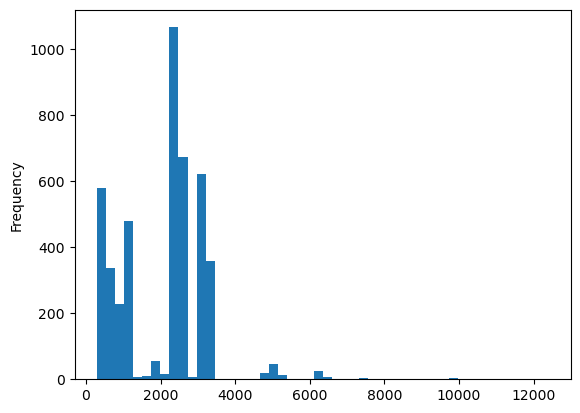

In [58]:
items.plot.hist(bins=50)

In [59]:
items[items.isin([1000,2000])]

Series([], Name: item_price, dtype: float64)

In [60]:
items[(items>1000) & (items<2000)]

item_name
Chips and Guacamole    1246.0
Chips and Guacamole    1246.0
Chips and Guacamole    1246.0
Chips and Guacamole    1246.0
Chips and Guacamole    1246.0
                        ...  
Chips and Guacamole    1246.0
Chips and Guacamole    1246.0
Chips and Guacamole    1246.0
Chips and Guacamole    1246.0
Chips and Guacamole    1246.0
Name: item_price, Length: 553, dtype: float64